### Celle 1 — Biblioteker
**Overvejelse:** Vi samler imports i starten, så notebooken er overskuelig og reproducerbar.

**Hvorfor metoderne bruges:**
- `pandas`/`numpy` til datahåndtering og beregninger
- `matplotlib`/`seaborn` til visualisering af tidsserier
- `scipy.signal` til signal- og støjrelaterede metoder (hvis nødvendigt)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
from IPython.display import display


### Celle 2 — Indlæsning af data
**Overvejelse:** Train- og testfiler indlæses separat, så datastrukturen kan verificeres inden de kombineres.

**Hvorfor metoden bruges:** Tidlig kontrol af inputdata reducerer risikoen for fejl senere i analysen.

In [4]:
print("Loader Train og Test data...")
train_df = pd.read_csv('DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('DailyDelhiClimateTest.csv')

Loader Train og Test data...


### Celle 3 — Samle og klargør tidsserier
**Overvejelse:** Vi kombinerer datasættene, sorterer på dato og vælger numeriske kolonner, så tidsserieanalysen bliver konsistent.

**Hvorfor metoden bruges:** Korrekt tidsorden og ensartede variabler er nødvendigt for at kunne vurdere støj og anvende vinduesmetoden korrekt.

In [5]:
# Kombiner train og test, så vi analyserer hele tidsforløbet
climate_df = pd.concat([train_df, test_df], ignore_index=True)
climate_df['date'] = pd.to_datetime(climate_df['date'])
climate_df = climate_df.sort_values('date').reset_index(drop=True)

# Vaelg numeriske tidsserier
numeric_cols = climate_df.select_dtypes(include='number').columns.tolist()
print('Numeriske tidsserier:', numeric_cols)

climate_df.head()

Numeriske tidsserier: ['meantemp', 'humidity', 'wind_speed', 'meanpressure']


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### Celle 4 — Vurdering af støjniveau via datavisualisering
**Overvejelse:** Støjniveau vurderes ved at sammenligne original signalserie med en glattet trend (7-dages glidende gennemsnit).

**Hvorfor metoden bruges:**
- Original vs. trend viser, hvor meget kortsigtet variation der findes
- Residualen (`støj = original - trend`) isolerer støjkomponenten
- `noise_ratio = std(støj) / std(original)` giver en enkel, sammenlignelig måling på tværs af serier

**Fortolkning:**
- Lav `noise_ratio` indikerer lav støj
- Høj `noise_ratio` indikerer, at en stor del af variationen er kortsigtede udsving

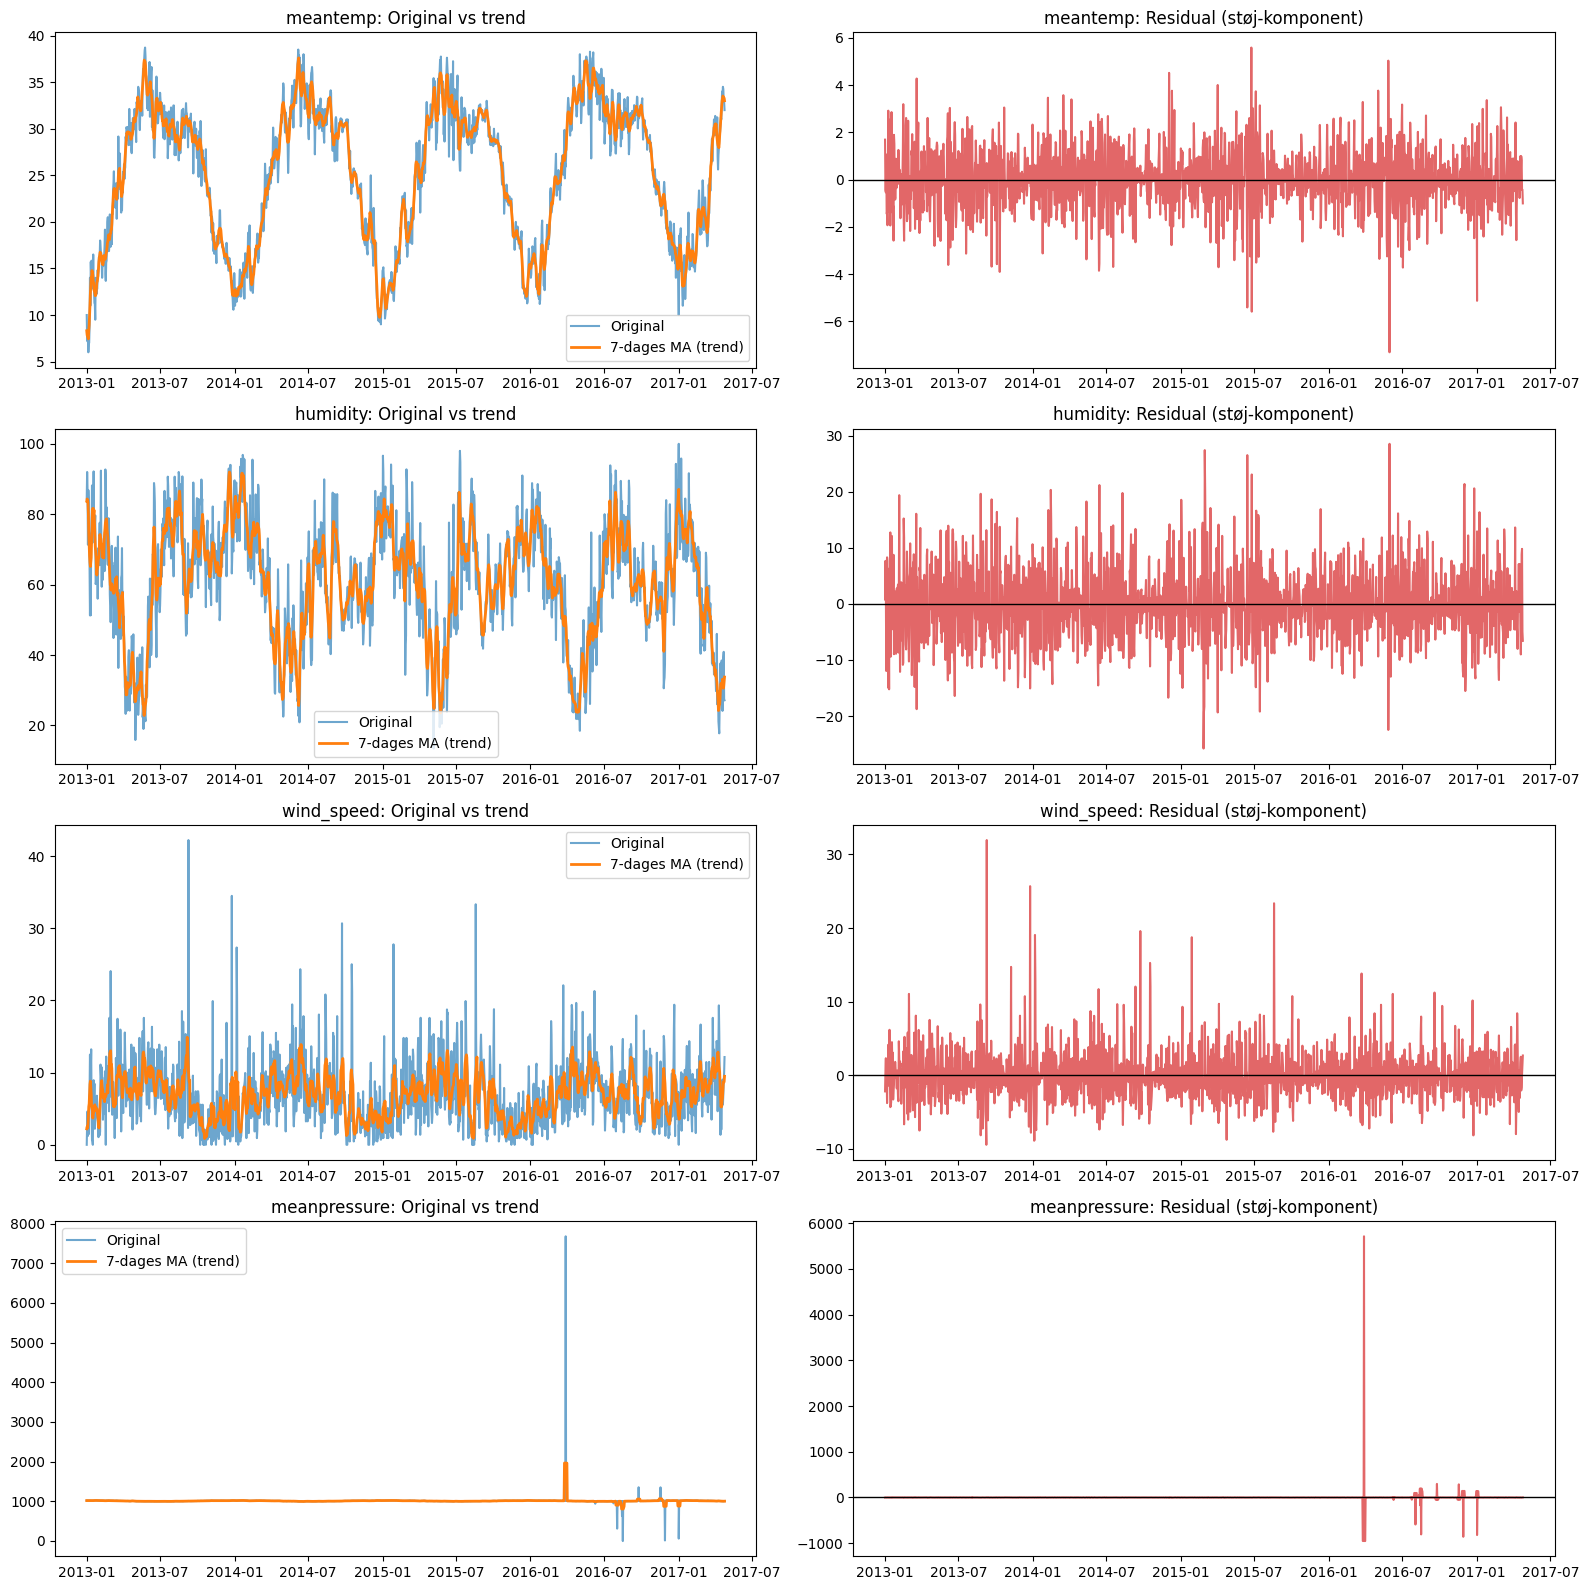

Vurderet støjniveau pr. tidsserie:


,serie,noise_ratio,vurdering
3,meanpressure,0.923,Høj støj
2,wind_speed,0.774,Høj støj
1,humidity,0.385,Moderat støj
0,meantemp,0.176,Lav støj


In [ ]:
window = 7  # 7-dages moving average til trendestimat # Vigtigt at uddyde med en kommentar om hvorfor 7 dage er valgt
noise_summary = []

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(16, 4 * len(numeric_cols)), sharex=False)
if len(numeric_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(numeric_cols):
    s = climate_df[col]
    trend = s.rolling(window=window, center=True, min_periods=1).mean()
    noise = s - trend

    noise_ratio = noise.std() / s.std() if s.std() != 0 else 0 # uddybende kommentar om hvorfor vi bruger standardafvigelse som mål for støj og hvorfor vi sammenligner det med den originale standardafvigelse
    if noise_ratio < 0.20:
        grade = 'Lav støj'
    elif noise_ratio < 0.40:
        grade = 'Moderat støj'
    else:
        grade = 'Høj støj'

    noise_summary.append({
        'serie': col,
        'noise_ratio': noise_ratio,
        'vurdering': grade
    })

    axes[i, 0].plot(climate_df['date'], s, label='Original', alpha=0.65)
    axes[i, 0].plot(climate_df['date'], trend, label=f'{window}-dages MA (trend)', linewidth=2)
    axes[i, 0].set_title(f'{col}: Original vs trend')
    axes[i, 0].legend()

    axes[i, 1].plot(climate_df['date'], noise, color='tab:red', alpha=0.7)
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'{col}: Residual (støj-komponent)')

plt.tight_layout()
plt.show()

noise_df = pd.DataFrame(noise_summary).sort_values('noise_ratio', ascending=False)
noise_df['noise_ratio'] = noise_df['noise_ratio'].round(3)
print('Vurderet støjniveau pr. tidsserie:')
display(noise_df)

### Celle 5 — Præprocessering med vinduesmetoden (for/efter)
**Overvejelse:** Som præprocessering anvendes et 7-dages glidende gennemsnit, der reducerer støj uden at fjerne den overordnede udvikling i tidsserien.

**Metode (vinduesmetoden):**
$$
x_t^{(smooth)} = \frac{1}{7}\sum_{i=0}^{6} x_{t-i}
$$

**Hvorfor metoden bruges:**
- Dæmper dag-til-dag udsving
- Gør trend og mønstre tydeligere
- Forbereder data bedre til videre analyse/modellering

**Plot før og efter:** I den næste kodecelle vises original data (før) og glattet data (efter) i samme figur for hver numerisk tidsserie.

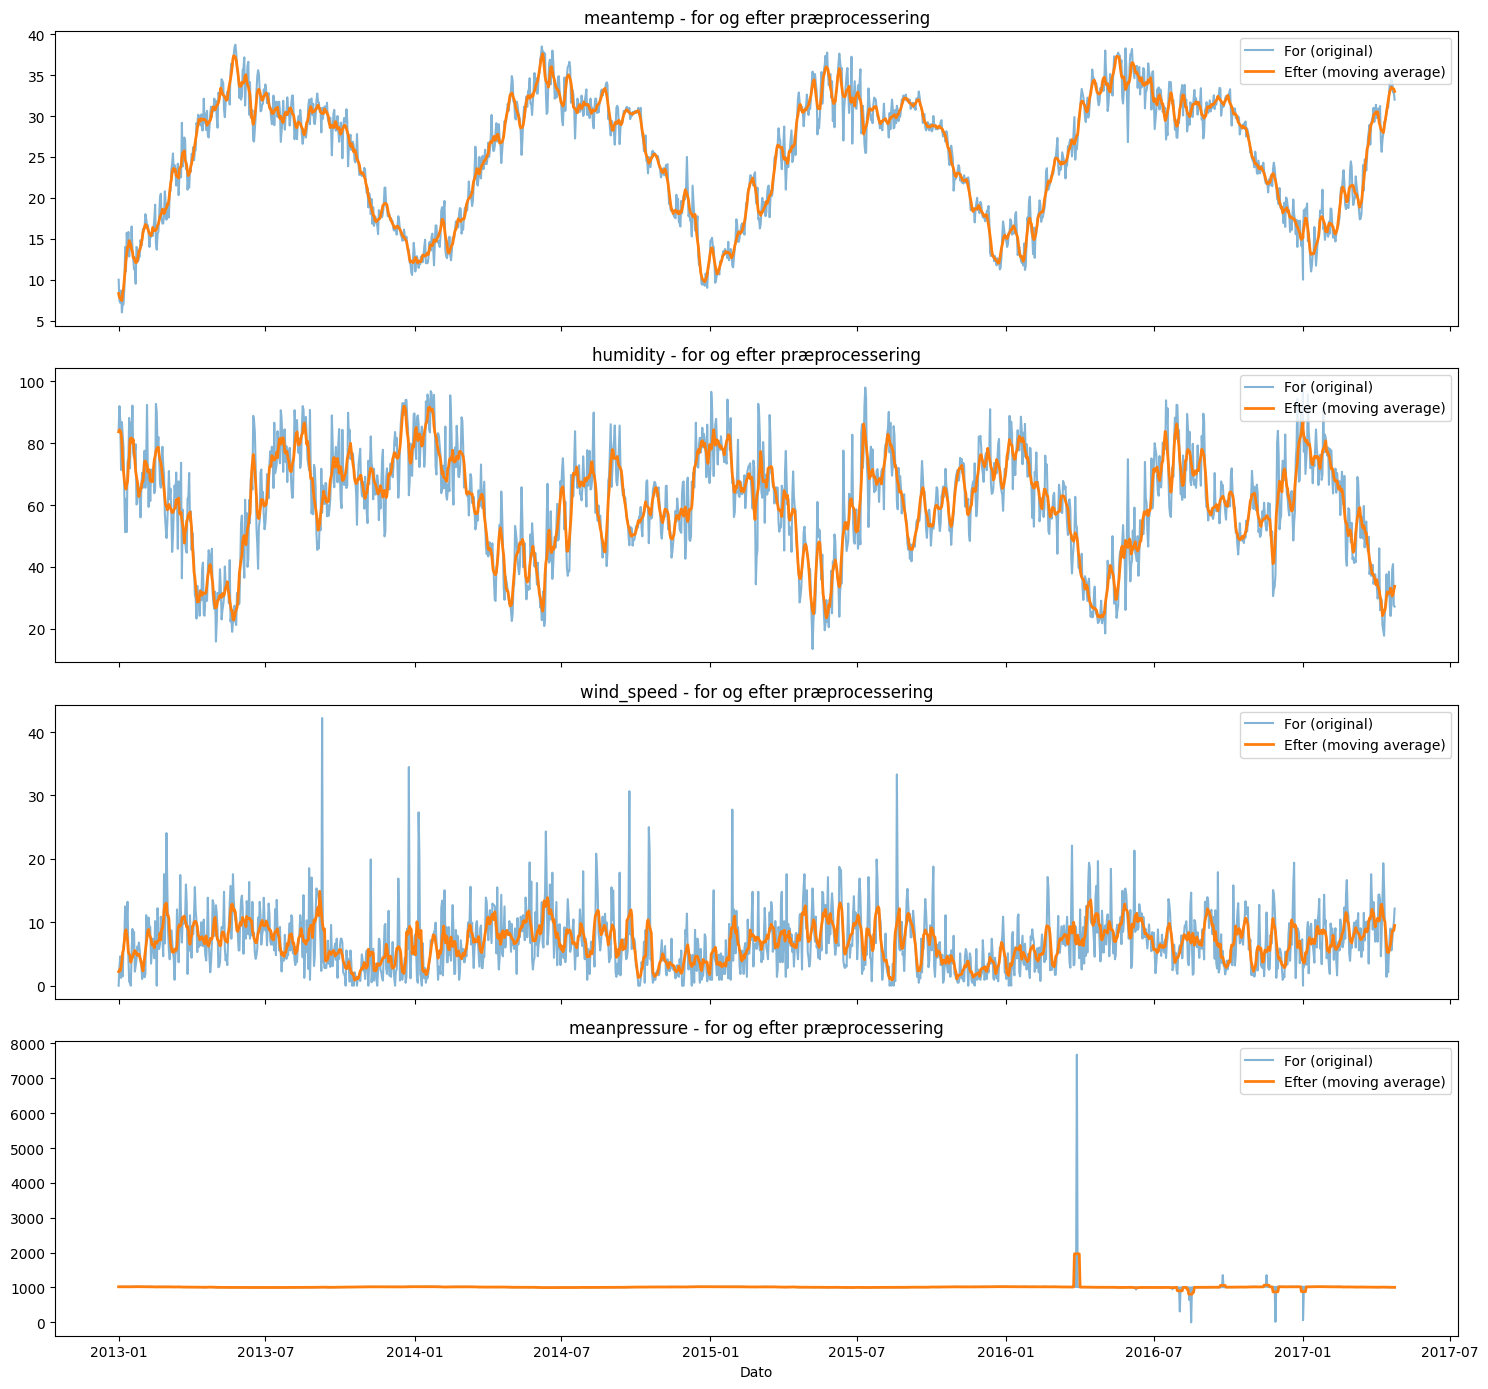

In [7]:
# Smoothet version af alle numeriske tidsserier
smoothed_df = climate_df.copy()
for col in numeric_cols:
    smoothed_df[col] = climate_df[col].rolling(window=window, center=True, min_periods=1).mean()

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(15, 3.5 * len(numeric_cols)), sharex=True)
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    axes[i].plot(climate_df['date'], climate_df[col], label='For (original)', alpha=0.55)
    axes[i].plot(smoothed_df['date'], smoothed_df[col], label='Efter (moving average)', linewidth=2)
    axes[i].set_title(f'{col} - for og efter præprocessering')
    axes[i].legend(loc='upper right')

plt.xlabel('Dato')
plt.tight_layout()
plt.show()